## Assignment 2 Mini Project

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task 1 — Data Preparation

In [8]:
def load_signals(folder):
    signals = []

    # Ensure consistent order (VERY IMPORTANT)
    signal_files = sorted(os.listdir(folder))

    for file in signal_files:
        file_path = os.path.join(folder, file)
        data = np.loadtxt(file_path)
        signals.append(data)

    signals = np.array(signals)

    # reshape → [samples, 128, 9]
    return np.transpose(signals, (1, 2, 0))


# ✅ Correct paths
X_train = load_signals("/content/drive/MyDrive/train/Inertial Signals")
X_test  = load_signals("/content/drive/MyDrive/test/Inertial Signals")

# Labels
y_train = np.loadtxt("/content/drive/MyDrive/train/y_train.txt") - 1
y_test  = np.loadtxt("/content/drive/MyDrive/test/y_test.txt") - 1

In [9]:
mean = X_train.mean(axis=(0,1))
std  = X_train.std(axis=(0,1)) + 1e-8

X_train = (X_train - mean) / std
X_test  = (X_test - mean) / std

In [10]:
from collections import Counter
print(Counter(y_train))

Counter({np.float64(5.0): 1407, np.float64(4.0): 1374, np.float64(3.0): 1286, np.float64(0.0): 1226, np.float64(1.0): 1073, np.float64(2.0): 986})


In [11]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(weights, dtype=torch.float32)

## Task 2 — Three Model Implementations

Vannilla model

In [12]:
import torch.nn as nn

class VanillaLSTM(nn.Module):
    def __init__(self, input_size=9, hidden_size=128, num_classes=6):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last time step
        out = self.dropout(out)
        return self.fc(out)

LSTM

In [13]:
class StackedLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm1 = nn.LSTM(9, 128, batch_first=True)
        self.norm = nn.LayerNorm(128)
        self.lstm2 = nn.LSTM(128, 64, batch_first=True)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(64, 6)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.norm(out)
        out, _ = self.lstm2(out)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

CNN-LSTM

In [14]:
class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(9, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(128, 128, batch_first=True)
        self.fc = nn.Linear(128, 6)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, C, T]
        x = self.conv(x)
        x = x.permute(0, 2, 1)  # [B, T, C]

        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

## Task 3 — Training

In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

In [16]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_t, y_train_t, test_size=0.2, stratify=y_train_t
)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(weights, dtype=torch.float32)

In [18]:
import torch.nn as nn
import time

def train_model(model, train_loader, val_loader, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        start_time = time.time()

        # 🔹 Training
        model.train()
        total_loss, correct = 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()

            # ✅ Gradient clipping (important)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)

            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == y).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / len(train_loader.dataset)

        # 🔹 Validation
        model.eval()
        total_loss, correct = 0, 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)

                loss = criterion(outputs, y)
                total_loss += loss.item()
                correct += (outputs.argmax(1) == y).sum().item()

        val_loss = total_loss / len(val_loader)
        val_acc  = correct / len(val_loader.dataset)

        scheduler.step()

        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {epoch_time:.2f}s")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs

In [19]:
model_A = VanillaLSTM()
model_B = StackedLSTM()
model_C = CNN_LSTM()

hist_A = train_model(model_A, train_loader, val_loader)
hist_B = train_model(model_B, train_loader, val_loader)
hist_C = train_model(model_C, train_loader, val_loader)

Epoch 01 | Train Loss: 1.2340 | Val Loss: 0.7980 | Train Acc: 0.5355 | Val Acc: 0.7220 | Time: 1.45s
Epoch 02 | Train Loss: 0.6934 | Val Loss: 0.5344 | Train Acc: 0.7337 | Val Acc: 0.7763 | Time: 0.39s
Epoch 03 | Train Loss: 0.4627 | Val Loss: 0.4431 | Train Acc: 0.8089 | Val Acc: 0.8430 | Time: 0.38s
Epoch 04 | Train Loss: 0.3487 | Val Loss: 0.2320 | Train Acc: 0.8842 | Val Acc: 0.9164 | Time: 0.44s
Epoch 05 | Train Loss: 0.2266 | Val Loss: 0.1807 | Train Acc: 0.9264 | Val Acc: 0.9375 | Time: 0.45s
Epoch 06 | Train Loss: 0.1844 | Val Loss: 0.3414 | Train Acc: 0.9378 | Val Acc: 0.8865 | Time: 0.44s
Epoch 07 | Train Loss: 0.1663 | Val Loss: 0.1445 | Train Acc: 0.9403 | Val Acc: 0.9456 | Time: 0.44s
Epoch 08 | Train Loss: 0.2249 | Val Loss: 0.1665 | Train Acc: 0.9184 | Val Acc: 0.9327 | Time: 0.44s
Epoch 09 | Train Loss: 0.1412 | Val Loss: 0.1277 | Train Acc: 0.9473 | Val Acc: 0.9483 | Time: 0.45s
Epoch 10 | Train Loss: 0.1187 | Val Loss: 0.1352 | Train Acc: 0.9558 | Val Acc: 0.9402 | Ti

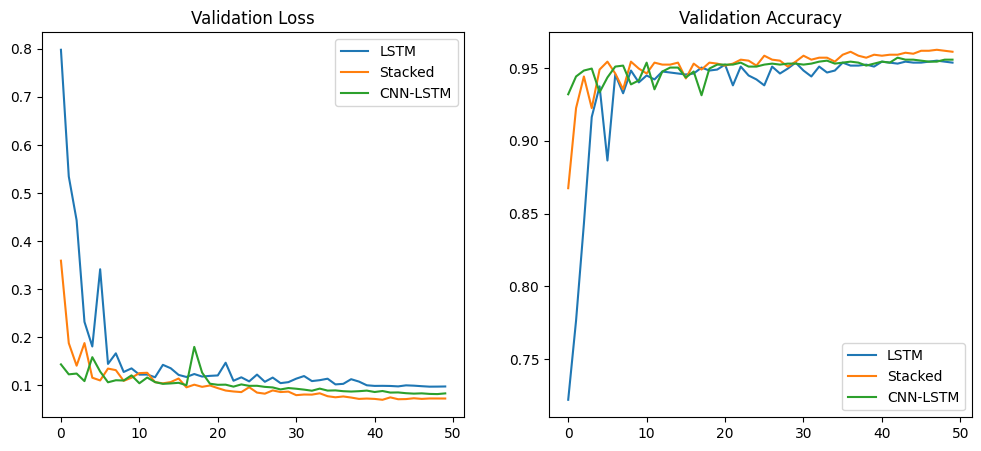

In [20]:
import matplotlib.pyplot as plt

def plot_curves(hist_A, hist_B, hist_C):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(hist_A[1], label="LSTM")
    plt.plot(hist_B[1], label="Stacked")
    plt.plot(hist_C[1], label="CNN-LSTM")
    plt.title("Validation Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(hist_A[3], label="LSTM")
    plt.plot(hist_B[3], label="Stacked")
    plt.plot(hist_C[3], label="CNN-LSTM")
    plt.title("Validation Accuracy")
    plt.legend()

    plt.show()

plot_curves(hist_A, hist_B, hist_C)

## Task 4 — Evaluation

In [21]:
import torch

def get_predictions(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            outputs = model(X)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_preds)

In [22]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

def evaluate_model(model, loader, name):
    y_true, y_pred = get_predictions(model, loader)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n{name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")

    print("\nDetailed Report:")
    print(classification_report(y_true, y_pred))

    return y_true, y_pred

In [23]:
y_true_A, y_pred_A = evaluate_model(model_A, test_loader, "Vanilla LSTM")
y_true_B, y_pred_B = evaluate_model(model_B, test_loader, "Stacked LSTM")
y_true_C, y_pred_C = evaluate_model(model_C, test_loader, "CNN-LSTM")


Vanilla LSTM Results:
Accuracy: 0.9006
Macro F1: 0.9019

Detailed Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       496
           1       0.92      0.95      0.94       471
           2       0.90      0.97      0.94       420
           3       0.79      0.80      0.79       491
           4       0.82      0.80      0.81       532
           5       1.00      0.95      0.97       537

    accuracy                           0.90      2947
   macro avg       0.90      0.90      0.90      2947
weighted avg       0.90      0.90      0.90      2947


Stacked LSTM Results:
Accuracy: 0.9050
Macro F1: 0.9060

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       496
           1       0.98      0.95      0.96       471
           2       0.90      0.99      0.94       420
           3       0.79      0.74      0.76       491
           4       0.78      0.82   

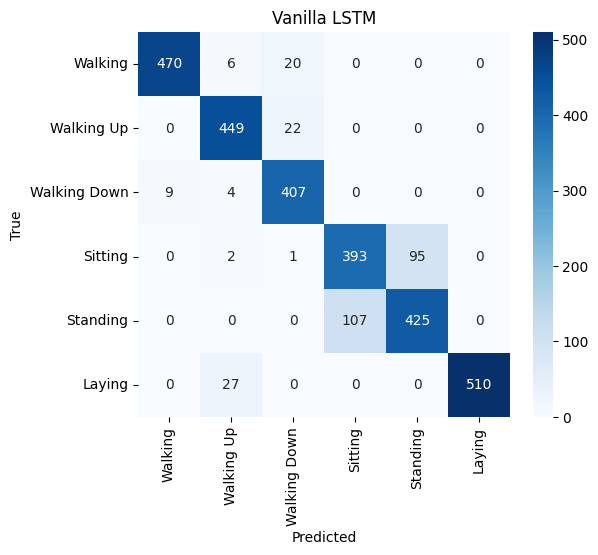

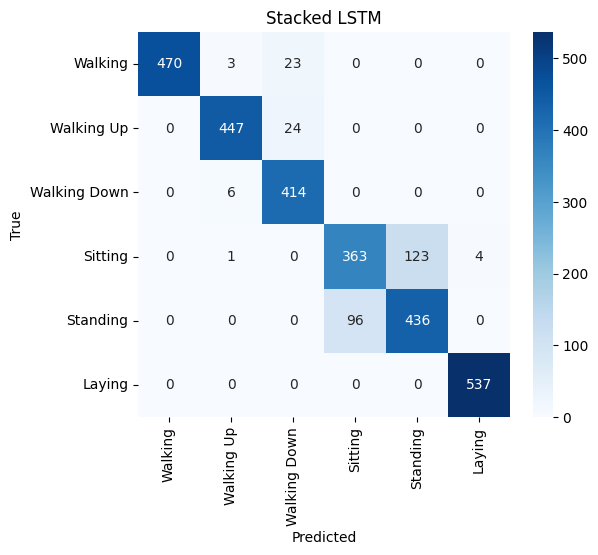

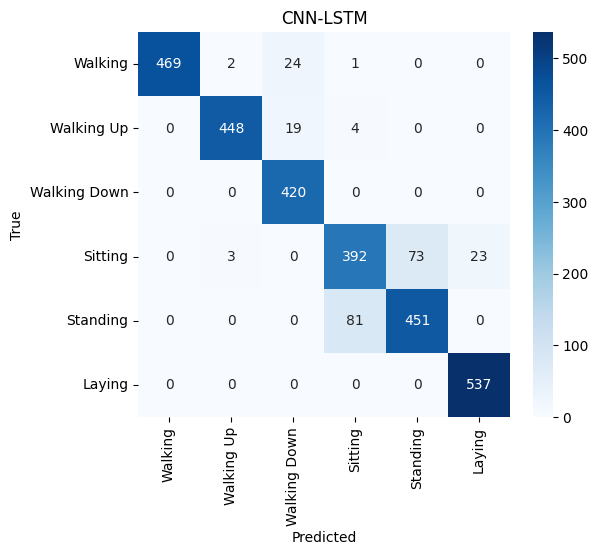

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = ["Walking", "Walking Up", "Walking Down", "Sitting", "Standing", "Laying"]

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_cm(y_true_A, y_pred_A, "Vanilla LSTM")
plot_cm(y_true_B, y_pred_B, "Stacked LSTM")
plot_cm(y_true_C, y_pred_C, "CNN-LSTM")

In [25]:
import time

def measure_latency(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    X, _ = next(iter(loader))
    X = X.to(device)

    start = time.time()
    with torch.no_grad():
        model(X)
    end = time.time()

    latency = (end - start) / X.shape[0]
    return latency

print("Latency per sample:")
print("LSTM:", measure_latency(model_A, test_loader))
print("Stacked:", measure_latency(model_B, test_loader))
print("CNN-LSTM:", measure_latency(model_C, test_loader))

Latency per sample:
LSTM: 1.4439225196838379e-05
Stacked: 1.6987323760986328e-05
CNN-LSTM: 2.4352222681045532e-05


## Task 5 — Temporal Interpretability

In [27]:
target_layer = model_C.conv[-3]
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

In [28]:
import torch.nn.functional as F

def compute_gradcam(model, input_tensor, class_idx):
    model.zero_grad()

    output = model(input_tensor)
    score = output[:, class_idx]

    score.backward()

    # Get stored values
    act = activations[-1]       # [B, C, T]
    grad = gradients[-1]        # [B, C, T]

    # Global average pooling over time
    weights = grad.mean(dim=2, keepdim=True)

    cam = (weights * act).sum(dim=1)  # [B, T]
    cam = F.relu(cam)

    # Normalize
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()

In [29]:
# Example indices
idx_walking = np.where(y_test == 0)[0][0]
idx_sitting = np.where(y_test == 3)[0][0]

sample_walking = X_test_t[idx_walking].unsqueeze(0)
sample_sitting = X_test_t[idx_sitting].unsqueeze(0)

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_C.to(device)
model_C.train()   # 🔥 REQUIRED for Grad-CAM

cam_walking = compute_gradcam(model_C, sample_walking.to(device), class_idx=0)
cam_sitting = compute_gradcam(model_C, sample_sitting.to(device), class_idx=3)

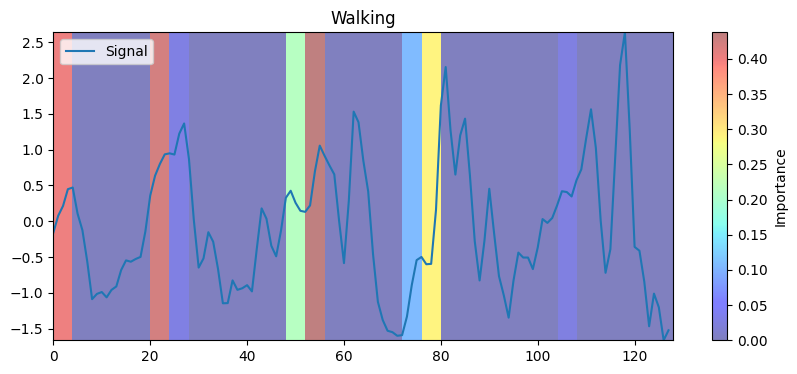

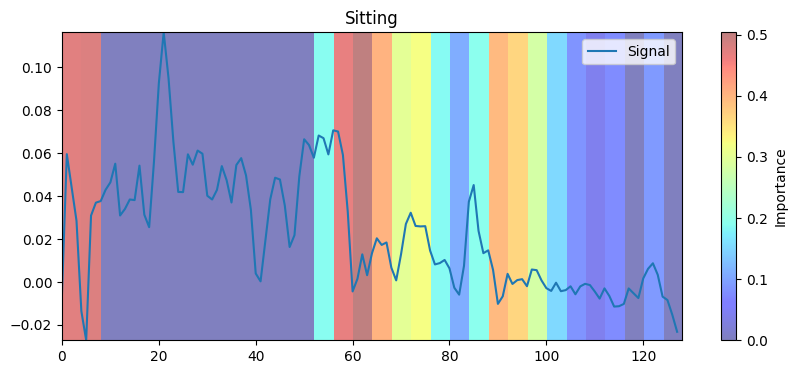

In [32]:
import matplotlib.pyplot as plt

def plot_gradcam(signal, cam, title):
    signal = signal.numpy()

    plt.figure(figsize=(10,4))

    # Plot one channel (e.g., acc_x)
    plt.plot(signal[:, 0], label='Signal')

    # Overlay heatmap
    plt.imshow(cam.reshape(1, -1),
               aspect='auto',
               cmap='jet',
               alpha=0.5,
               extent=[0, 128, signal[:,0].min(), signal[:,0].max()])

    plt.title(title)
    plt.colorbar(label='Importance')
    plt.legend()
    plt.show()

plot_gradcam(sample_walking.squeeze(), cam_walking[0], "Walking")
plot_gradcam(sample_sitting.squeeze(), cam_sitting[0], "Sitting")